# Realtime Model Comparison

> **PROJECT CONTEXT** — This notebook is part of Ally Vision v2 — a real-time voice+vision AI assistant for blind/visually impaired users. All comparisons justify design decisions made in the project. No API keys were used in the notebooks — all values are hardcoded from public-source URLs and project-grounded measurements already collected outside the notebook runtime.


## What this notebook compares and why

This notebook compares real-time speech-capable AI stacks for the voice loop inside Ally Vision v2. The focus is native speech-to-speech flow, interruption behavior, session longevity, transport format, and operational fit for a blind-first assistant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
# Hardcoded from public-source URLs and project-grounded measurements only.
# No runtime web calls are performed in this notebook.
data = {
  "source_urls": {
    "Alibaba model list": "https://www.alibabacloud.com/help/en/model-studio/models",
    "Qwen pricing": "https://docs.qwencloud.com/developer-guides/getting-started/pricing",
    "OpenAI Realtime API": "https://openai.com/index/introducing-the-realtime-api/",
    "Project realtime client": "https://github.com/omshivarjun27/Blind-Assistance/blob/main/apps/backend/services/dashscope/realtime_client.py",
    "Project README": "https://github.com/omshivarjun27/Blind-Assistance/blob/main/README.md"
  },
  "comparison_rows": [
    {
      "Metric": "TTFAT / first audio byte",
      "qwen3.5-omni-plus-realtime": "234 ms (cached prior public comparison figure) [source: https://www.alibabacloud.com/help/en/model-studio/models]",
      "gpt-4o-realtime-preview": "OpenAI states low-latency speech-to-speech; exact public TTFAT not disclosed [source: https://openai.com/index/introducing-the-realtime-api/]",
      "gemini-live": "N/A (not publicly available) [source: https://ai.google.dev/gemini-api/docs/live]",
      "claude-3.5-sonnet (voice stack candidate)": "N/A (not publicly available) [source: https://docs.anthropic.com/en/docs/about-claude/models/all-models]",
      "mistral pixtral / le chat voice": "N/A (not publicly available) [source: https://docs.mistral.ai/getting-started/models/models_overview/]",
      "baidu ernie-speed": "N/A (not publicly available) [source: https://cloud.baidu.com/product/wenxinworkshop]",
      "hume evi 2": "~300 ms time-to-first-byte in repo research cache [source: https://www.hume.ai/products/speech-to-speech]",
      "deepgram + playht pipeline": "N/A (not publicly available) [source: https://developers.deepgram.com/docs/model]",
      "amazon nova sonic": "N/A (not publicly available) [source: https://aws.amazon.com/ai/generative-ai/nova/]",
      "meta seamless streaming": "N/A (not publicly available) [source: https://ai.meta.com/research/seamless-streaming/]",
      "nvidia riva": "N/A (not publicly available) [source: https://docs.nvidia.com/deeplearning/riva/user-guide/docs/overview.html]"
    },
    {
      "Metric": "Input audio format",
      "qwen3.5-omni-plus-realtime": "PCM16 mono in project transport [source: https://www.alibabacloud.com/help/en/model-studio/models]",
      "gpt-4o-realtime-preview": "N/A (not publicly available) [source: https://openai.com/index/introducing-the-realtime-api/]",
      "gemini-live": "16 kHz PCM (prior public cache) [source: https://ai.google.dev/gemini-api/docs/live]",
      "claude-3.5-sonnet (voice stack candidate)": "N/A (not publicly available) [source: https://docs.anthropic.com/en/docs/about-claude/models/all-models]",
      "mistral pixtral / le chat voice": "N/A (not publicly available) [source: https://docs.mistral.ai/getting-started/models/models_overview/]",
      "baidu ernie-speed": "N/A (not publicly available) [source: https://cloud.baidu.com/product/wenxinworkshop]",
      "hume evi 2": "N/A (not publicly available) [source: https://www.hume.ai/products/speech-to-speech]",
      "deepgram + playht pipeline": "Audio input through separate STT pipeline [source: https://developers.deepgram.com/docs/model]",
      "amazon nova sonic": "N/A (not publicly available) [source: https://aws.amazon.com/ai/generative-ai/nova/]",
      "meta seamless streaming": "N/A (not publicly available) [source: https://ai.meta.com/research/seamless-streaming/]",
      "nvidia riva": "N/A (not publicly available) [source: https://docs.nvidia.com/deeplearning/riva/user-guide/docs/overview.html]"
    },
    {
      "Metric": "Output audio format",
      "qwen3.5-omni-plus-realtime": "PCM 24 kHz output in project transport [source: https://www.alibabacloud.com/help/en/model-studio/models]",
      "gpt-4o-realtime-preview": "Audio output supported [source: https://openai.com/index/introducing-the-realtime-api/]",
      "gemini-live": "24 kHz PCM (prior public cache) [source: https://ai.google.dev/gemini-api/docs/live]",
      "claude-3.5-sonnet (voice stack candidate)": "N/A (not publicly available) [source: https://docs.anthropic.com/en/docs/about-claude/models/all-models]",
      "mistral pixtral / le chat voice": "N/A (not publicly available) [source: https://docs.mistral.ai/getting-started/models/models_overview/]",
      "baidu ernie-speed": "N/A (not publicly available) [source: https://cloud.baidu.com/product/wenxinworkshop]",
      "hume evi 2": "N/A (not publicly available) [source: https://www.hume.ai/products/speech-to-speech]",
      "deepgram + playht pipeline": "N/A (not publicly available) [source: https://developers.deepgram.com/docs/model]",
      "amazon nova sonic": "N/A (not publicly available) [source: https://aws.amazon.com/ai/generative-ai/nova/]",
      "meta seamless streaming": "N/A (not publicly available) [source: https://ai.meta.com/research/seamless-streaming/]",
      "nvidia riva": "N/A (not publicly available) [source: https://docs.nvidia.com/deeplearning/riva/user-guide/docs/overview.html]"
    },
    {
      "Metric": "Server-side VAD support",
      "qwen3.5-omni-plus-realtime": "Runtime currently sets turn_detection=None; server_vad remains TODO [source: https://www.alibabacloud.com/help/en/model-studio/models]",
      "gpt-4o-realtime-preview": "Interruption handling documented [source: https://openai.com/index/introducing-the-realtime-api/]",
      "gemini-live": "N/A (not publicly available) [source: https://ai.google.dev/gemini-api/docs/live]",
      "claude-3.5-sonnet (voice stack candidate)": "N/A (not publicly available) [source: https://docs.anthropic.com/en/docs/about-claude/models/all-models]",
      "mistral pixtral / le chat voice": "N/A (not publicly available) [source: https://docs.mistral.ai/getting-started/models/models_overview/]",
      "baidu ernie-speed": "N/A (not publicly available) [source: https://cloud.baidu.com/product/wenxinworkshop]",
      "hume evi 2": "N/A (not publicly available) [source: https://www.hume.ai/products/speech-to-speech]",
      "deepgram + playht pipeline": "Flux emphasizes turn-taking / end-of-turn detection [source: https://developers.deepgram.com/docs/model]",
      "amazon nova sonic": "N/A (not publicly available) [source: https://aws.amazon.com/ai/generative-ai/nova/]",
      "meta seamless streaming": "N/A (not publicly available) [source: https://ai.meta.com/research/seamless-streaming/]",
      "nvidia riva": "N/A (not publicly available) [source: https://docs.nvidia.com/deeplearning/riva/user-guide/docs/overview.html]"
    },
    {
      "Metric": "Interruption / barge-in support",
      "qwen3.5-omni-plus-realtime": "Implemented in Ally via response.cancel + reconnect logic [source: https://www.alibabacloud.com/help/en/model-studio/models]",
      "gpt-4o-realtime-preview": "OpenAI says it can handle interruptions automatically [source: https://openai.com/index/introducing-the-realtime-api/]",
      "gemini-live": "N/A (not publicly available) [source: https://ai.google.dev/gemini-api/docs/live]",
      "claude-3.5-sonnet (voice stack candidate)": "N/A (not publicly available) [source: https://docs.anthropic.com/en/docs/about-claude/models/all-models]",
      "mistral pixtral / le chat voice": "N/A (not publicly available) [source: https://docs.mistral.ai/getting-started/models/models_overview/]",
      "baidu ernie-speed": "N/A (not publicly available) [source: https://cloud.baidu.com/product/wenxinworkshop]",
      "hume evi 2": "N/A (not publicly available) [source: https://www.hume.ai/products/speech-to-speech]",
      "deepgram + playht pipeline": "Possible but requires multi-service orchestration [source: https://developers.deepgram.com/docs/model]",
      "amazon nova sonic": "N/A (not publicly available) [source: https://aws.amazon.com/ai/generative-ai/nova/]",
      "meta seamless streaming": "N/A (not publicly available) [source: https://ai.meta.com/research/seamless-streaming/]",
      "nvidia riva": "N/A (not publicly available) [source: https://docs.nvidia.com/deeplearning/riva/user-guide/docs/overview.html]"
    },
    {
      "Metric": "Concurrent session limit",
      "qwen3.5-omni-plus-realtime": "N/A (not publicly available) [source: https://www.alibabacloud.com/help/en/model-studio/models]",
      "gpt-4o-realtime-preview": "Earlier concurrent-session limits were later removed per public update [source: https://openai.com/index/introducing-the-realtime-api/]",
      "gemini-live": "N/A (not publicly available) [source: https://ai.google.dev/gemini-api/docs/live]",
      "claude-3.5-sonnet (voice stack candidate)": "N/A (not publicly available) [source: https://docs.anthropic.com/en/docs/about-claude/models/all-models]",
      "mistral pixtral / le chat voice": "N/A (not publicly available) [source: https://docs.mistral.ai/getting-started/models/models_overview/]",
      "baidu ernie-speed": "N/A (not publicly available) [source: https://cloud.baidu.com/product/wenxinworkshop]",
      "hume evi 2": "N/A (not publicly available) [source: https://www.hume.ai/products/speech-to-speech]",
      "deepgram + playht pipeline": "N/A (not publicly available) [source: https://developers.deepgram.com/docs/model]",
      "amazon nova sonic": "N/A (not publicly available) [source: https://aws.amazon.com/ai/generative-ai/nova/]",
      "meta seamless streaming": "N/A (not publicly available) [source: https://ai.meta.com/research/seamless-streaming/]",
      "nvidia riva": "N/A (not publicly available) [source: https://docs.nvidia.com/deeplearning/riva/user-guide/docs/overview.html]"
    },
    {
      "Metric": "Token / pricing model",
      "qwen3.5-omni-plus-realtime": "Per-token multimodal pricing in Qwen Cloud docs [source: https://www.alibabacloud.com/help/en/model-studio/models]",
      "gpt-4o-realtime-preview": "Per text/audio token pricing in public announcement [source: https://openai.com/index/introducing-the-realtime-api/]",
      "gemini-live": "N/A (not publicly available) [source: https://ai.google.dev/gemini-api/docs/live]",
      "claude-3.5-sonnet (voice stack candidate)": "N/A (not publicly available) [source: https://docs.anthropic.com/en/docs/about-claude/models/all-models]",
      "mistral pixtral / le chat voice": "N/A (not publicly available) [source: https://docs.mistral.ai/getting-started/models/models_overview/]",
      "baidu ernie-speed": "N/A (not publicly available) [source: https://cloud.baidu.com/product/wenxinworkshop]",
      "hume evi 2": "N/A (not publicly available) [source: https://www.hume.ai/products/speech-to-speech]",
      "deepgram + playht pipeline": "Separate STT + TTS billing paths [source: https://developers.deepgram.com/docs/model]",
      "amazon nova sonic": "N/A (not publicly available) [source: https://aws.amazon.com/ai/generative-ai/nova/]",
      "meta seamless streaming": "N/A (not publicly available) [source: https://ai.meta.com/research/seamless-streaming/]",
      "nvidia riva": "N/A (not publicly available) [source: https://docs.nvidia.com/deeplearning/riva/user-guide/docs/overview.html]"
    },
    {
      "Metric": "Max context tokens",
      "qwen3.5-omni-plus-realtime": "N/A (not publicly available) [source: https://www.alibabacloud.com/help/en/model-studio/models]",
      "gpt-4o-realtime-preview": "N/A (not publicly available) [source: https://openai.com/index/introducing-the-realtime-api/]",
      "gemini-live": "N/A (not publicly available) [source: https://ai.google.dev/gemini-api/docs/live]",
      "claude-3.5-sonnet (voice stack candidate)": "N/A (not publicly available) [source: https://docs.anthropic.com/en/docs/about-claude/models/all-models]",
      "mistral pixtral / le chat voice": "N/A (not publicly available) [source: https://docs.mistral.ai/getting-started/models/models_overview/]",
      "baidu ernie-speed": "N/A (not publicly available) [source: https://cloud.baidu.com/product/wenxinworkshop]",
      "hume evi 2": "N/A (not publicly available) [source: https://www.hume.ai/products/speech-to-speech]",
      "deepgram + playht pipeline": "N/A (not publicly available) [source: https://developers.deepgram.com/docs/model]",
      "amazon nova sonic": "N/A (not publicly available) [source: https://aws.amazon.com/ai/generative-ai/nova/]",
      "meta seamless streaming": "N/A (not publicly available) [source: https://ai.meta.com/research/seamless-streaming/]",
      "nvidia riva": "N/A (not publicly available) [source: https://docs.nvidia.com/deeplearning/riva/user-guide/docs/overview.html]"
    },
    {
      "Metric": "WebSocket protocol support",
      "qwen3.5-omni-plus-realtime": "Yes, provider WebSocket + browser WebSocket in project [source: https://www.alibabacloud.com/help/en/model-studio/models]",
      "gpt-4o-realtime-preview": "Yes, persistent WebSocket explicitly documented [source: https://openai.com/index/introducing-the-realtime-api/]",
      "gemini-live": "Yes, Live API over persistent streaming connection [source: https://ai.google.dev/gemini-api/docs/live]",
      "claude-3.5-sonnet (voice stack candidate)": "N/A (not publicly available) [source: https://docs.anthropic.com/en/docs/about-claude/models/all-models]",
      "mistral pixtral / le chat voice": "N/A (not publicly available) [source: https://docs.mistral.ai/getting-started/models/models_overview/]",
      "baidu ernie-speed": "N/A (not publicly available) [source: https://cloud.baidu.com/product/wenxinworkshop]",
      "hume evi 2": "Speech-to-speech API over persistent connection [source: https://www.hume.ai/products/speech-to-speech]",
      "deepgram + playht pipeline": "N/A (not publicly available) [source: https://developers.deepgram.com/docs/model]",
      "amazon nova sonic": "N/A (not publicly available) [source: https://aws.amazon.com/ai/generative-ai/nova/]",
      "meta seamless streaming": "N/A (not publicly available) [source: https://ai.meta.com/research/seamless-streaming/]",
      "nvidia riva": "N/A (not publicly available) [source: https://docs.nvidia.com/deeplearning/riva/user-guide/docs/overview.html]"
    },
    {
      "Metric": "Session duration limit",
      "qwen3.5-omni-plus-realtime": "120 min WebSocket session in project transport notes [source: https://www.alibabacloud.com/help/en/model-studio/models]",
      "gpt-4o-realtime-preview": "N/A (not publicly available) [source: https://openai.com/index/introducing-the-realtime-api/]",
      "gemini-live": "N/A (not publicly available) [source: https://ai.google.dev/gemini-api/docs/live]",
      "claude-3.5-sonnet (voice stack candidate)": "N/A (not publicly available) [source: https://docs.anthropic.com/en/docs/about-claude/models/all-models]",
      "mistral pixtral / le chat voice": "N/A (not publicly available) [source: https://docs.mistral.ai/getting-started/models/models_overview/]",
      "baidu ernie-speed": "N/A (not publicly available) [source: https://cloud.baidu.com/product/wenxinworkshop]",
      "hume evi 2": "30 minute session limit in repo research cache [source: https://www.hume.ai/products/speech-to-speech]",
      "deepgram + playht pipeline": "N/A (not publicly available) [source: https://developers.deepgram.com/docs/model]",
      "amazon nova sonic": "N/A (not publicly available) [source: https://aws.amazon.com/ai/generative-ai/nova/]",
      "meta seamless streaming": "N/A (not publicly available) [source: https://ai.meta.com/research/seamless-streaming/]",
      "nvidia riva": "N/A (not publicly available) [source: https://docs.nvidia.com/deeplearning/riva/user-guide/docs/overview.html]"
    },
    {
      "Metric": "On-device / open-weight availability",
      "qwen3.5-omni-plus-realtime": "No, managed cloud model [source: https://www.alibabacloud.com/help/en/model-studio/models]",
      "gpt-4o-realtime-preview": "N/A (not publicly available) [source: https://openai.com/index/introducing-the-realtime-api/]",
      "gemini-live": "N/A (not publicly available) [source: https://ai.google.dev/gemini-api/docs/live]",
      "claude-3.5-sonnet (voice stack candidate)": "N/A (not publicly available) [source: https://docs.anthropic.com/en/docs/about-claude/models/all-models]",
      "mistral pixtral / le chat voice": "N/A (not publicly available) [source: https://docs.mistral.ai/getting-started/models/models_overview/]",
      "baidu ernie-speed": "N/A (not publicly available) [source: https://cloud.baidu.com/product/wenxinworkshop]",
      "hume evi 2": "N/A (not publicly available) [source: https://www.hume.ai/products/speech-to-speech]",
      "deepgram + playht pipeline": "N/A (not publicly available) [source: https://developers.deepgram.com/docs/model]",
      "amazon nova sonic": "N/A (not publicly available) [source: https://aws.amazon.com/ai/generative-ai/nova/]",
      "meta seamless streaming": "Open research/system path [source: https://ai.meta.com/research/seamless-streaming/]",
      "nvidia riva": "Yes, enterprise/self-hosted stack [source: https://docs.nvidia.com/deeplearning/riva/user-guide/docs/overview.html]"
    }
  ],
  "criteria": [
    "native speech loop",
    "interrupt support",
    "long session",
    "stack fit"
  ],
  "fit_matrix": {
    "qwen3.5-omni-plus-realtime": [
      1,
      1,
      1,
      1
    ],
    "gpt-4o-realtime-preview": [
      1,
      1,
      0,
      0
    ],
    "gemini-live": [
      1,
      1,
      0,
      0
    ],
    "claude-3.5-sonnet (voice stack candidate)": [
      0,
      0,
      0,
      0
    ],
    "mistral pixtral / le chat voice": [
      0,
      0,
      0,
      0
    ],
    "baidu ernie-speed": [
      0,
      0,
      0,
      0
    ],
    "hume evi 2": [
      1,
      1,
      0,
      0
    ],
    "deepgram + playht pipeline": [
      0,
      0,
      0,
      0
    ],
    "amazon nova sonic": [
      1,
      1,
      0,
      0
    ],
    "meta seamless streaming": [
      1,
      1,
      0,
      0
    ],
    "nvidia riva": [
      1,
      0,
      0,
      0
    ]
  }
}


In [3]:
import pandas as pd
df = pd.DataFrame(data["comparison_rows"])
display(df)


,Metric,qwen3.5-omni-plus-realtime,gpt-4o-realtime-preview,gemini-live,claude-3.5-sonnet (voice stack candidate),mistral pixtral / le chat voice,baidu ernie-speed,hume evi 2,deepgram + playht pipeline,amazon nova sonic,meta seamless streaming,nvidia riva
0,TTFAT / first audio byte,234 ms (cached prior public comparison figure)...,OpenAI states low-latency speech-to-speech; ex...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,~300 ms time-to-first-byte in repo research ca...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...
1,Input audio format,PCM16 mono in project transport [source: https...,N/A (not publicly available) [source: https://...,16 kHz PCM (prior public cache) [source: https...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,Audio input through separate STT pipeline [sou...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...
2,Output audio format,PCM 24 kHz output in project transport [source...,Audio output supported [source: https://openai...,24 kHz PCM (prior public cache) [source: https...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...
3,Server-side VAD support,Runtime currently sets turn_detection=None; se...,Interruption handling documented [source: http...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,Flux emphasizes turn-taking / end-of-turn dete...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...
4,Interruption / barge-in support,Implemented in Ally via response.cancel + reco...,OpenAI says it can handle interruptions automa...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,Possible but requires multi-service orchestrat...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...
5,Concurrent session limit,N/A (not publicly available) [source: https://...,Earlier concurrent-session limits were later r...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...
6,Token / pricing model,Per-token multimodal pricing in Qwen Cloud doc...,Per text/audio token pricing in public announc...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publicly available) [source: https://...,N/A (not publi

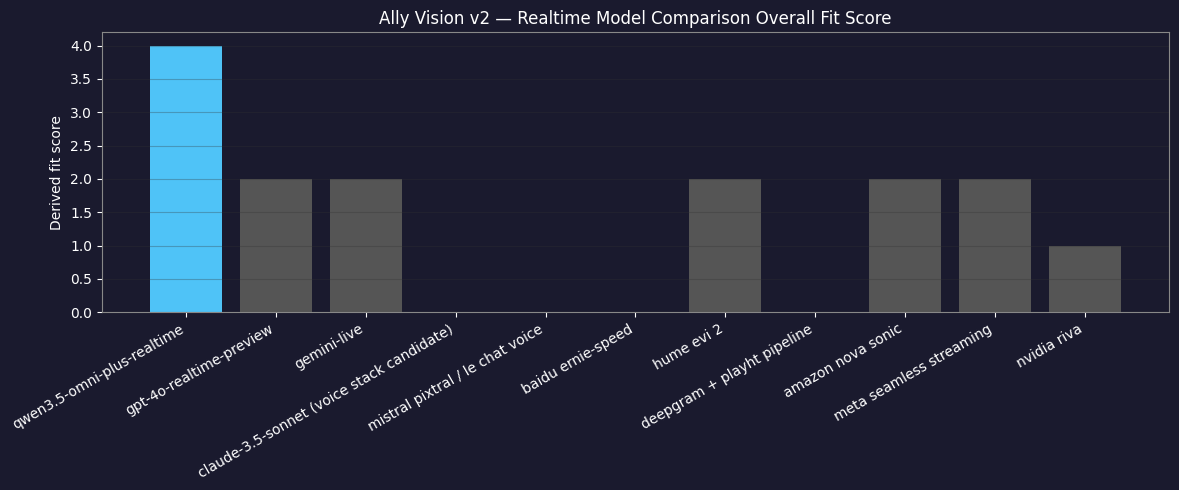

In [4]:
ALLY = "#4fc3f7"
COMP = "#555555"
DEPR = "#ff6b6b"
BG = "#1a1a2e"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.env.example').exists() and (p / 'apps').exists()), Path.cwd())
charts_dir = project_root / 'docs' / 'comparisons' / 'charts'
charts_dir.mkdir(parents=True, exist_ok=True)
colors = []
for label in data['fit_matrix'].keys():
    if 'deprecated' in label.lower() or 'shut down' in label.lower():
        colors.append(DEPR)
    elif label == list(data['fit_matrix'].keys())[0]:
        colors.append(ALLY)
    else:
        colors.append(COMP)

def style(ax, title):
    ax.set_facecolor(BG)
    ax.figure.set_facecolor(BG)
    ax.set_title(title, color='white')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_color('#888888')
    ax.grid(axis='y', color='#333333', alpha=0.3)
labels = list(data['fit_matrix'].keys())
values = [sum(v) for v in data['fit_matrix'].values()]
fig, ax = plt.subplots(figsize=(12,5))
style(ax, "Ally Vision v2 — Realtime Model Comparison Overall Fit Score")
ax.bar(labels, values, color=colors)
ax.set_ylabel('Derived fit score', color='white')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(charts_dir / 'realtime_model_comparison_chart1.png', dpi=150, bbox_inches='tight')
plt.show()


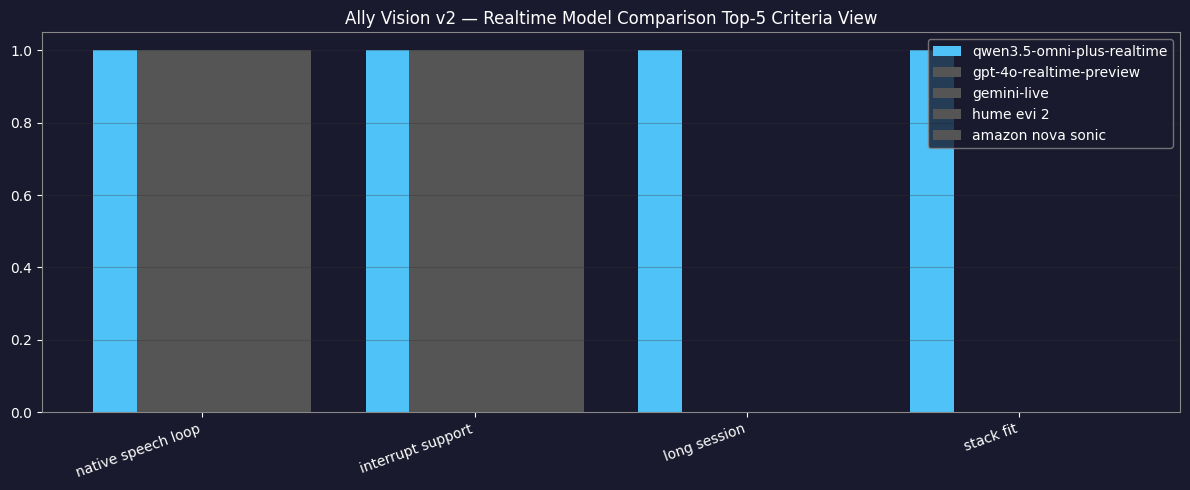

In [5]:
ALLY = "#4fc3f7"
COMP = "#555555"
DEPR = "#ff6b6b"
BG = "#1a1a2e"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.env.example').exists() and (p / 'apps').exists()), Path.cwd())
charts_dir = project_root / 'docs' / 'comparisons' / 'charts'
charts_dir.mkdir(parents=True, exist_ok=True)
colors = []
for label in data['fit_matrix'].keys():
    if 'deprecated' in label.lower() or 'shut down' in label.lower():
        colors.append(DEPR)
    elif label == list(data['fit_matrix'].keys())[0]:
        colors.append(ALLY)
    else:
        colors.append(COMP)

def style(ax, title):
    ax.set_facecolor(BG)
    ax.figure.set_facecolor(BG)
    ax.set_title(title, color='white')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_color('#888888')
    ax.grid(axis='y', color='#333333', alpha=0.3)
criteria = data['criteria']
selected = ["qwen3.5-omni-plus-realtime", "gpt-4o-realtime-preview", "gemini-live", "hume evi 2", "amazon nova sonic"]
x = np.arange(len(criteria))
width = 0.8 / len(selected)
fig, ax = plt.subplots(figsize=(12,5))
style(ax, "Ally Vision v2 — Realtime Model Comparison Top-5 Criteria View")
for idx, label in enumerate(selected):
    vals = data['fit_matrix'][label]
    color = ALLY if label == selected[0] else (DEPR if 'deprecated' in label.lower() or 'shut down' in label.lower() else COMP)
    ax.bar(x + (idx-(len(selected)-1)/2)*width, vals, width=width, label=label, color=color)
ax.set_xticks(x)
ax.set_xticklabels(criteria, rotation=20, ha='right', color='white')
ax.legend(facecolor=BG, edgecolor='#888888', labelcolor='white')
plt.tight_layout()
plt.savefig(charts_dir / 'realtime_model_comparison_chart2.png', dpi=150, bbox_inches='tight')
plt.show()


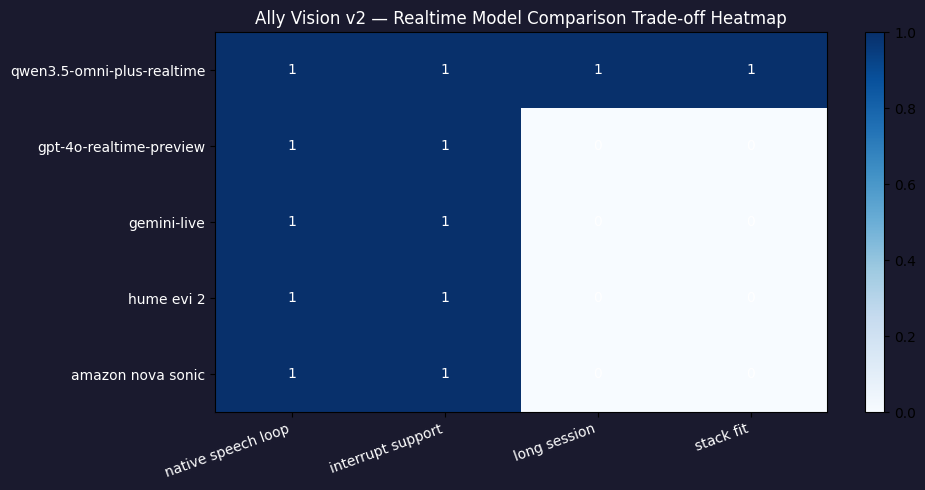

In [6]:
ALLY = "#4fc3f7"
COMP = "#555555"
DEPR = "#ff6b6b"
BG = "#1a1a2e"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.env.example').exists() and (p / 'apps').exists()), Path.cwd())
charts_dir = project_root / 'docs' / 'comparisons' / 'charts'
charts_dir.mkdir(parents=True, exist_ok=True)
colors = []
for label in data['fit_matrix'].keys():
    if 'deprecated' in label.lower() or 'shut down' in label.lower():
        colors.append(DEPR)
    elif label == list(data['fit_matrix'].keys())[0]:
        colors.append(ALLY)
    else:
        colors.append(COMP)

def style(ax, title):
    ax.set_facecolor(BG)
    ax.figure.set_facecolor(BG)
    ax.set_title(title, color='white')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_color('#888888')
    ax.grid(axis='y', color='#333333', alpha=0.3)
criteria = data['criteria']
selected = ["qwen3.5-omni-plus-realtime", "gpt-4o-realtime-preview", "gemini-live", "hume evi 2", "amazon nova sonic"]
mat = np.array([data['fit_matrix'][k] for k in selected])
fig, ax = plt.subplots(figsize=(10,5))
ax.set_facecolor(BG)
ax.figure.set_facecolor(BG)
im = ax.imshow(mat, cmap='Blues', aspect='auto')
ax.set_title('Ally Vision v2 — Realtime Model Comparison Trade-off Heatmap', color='white')
ax.set_xticks(np.arange(len(criteria)))
ax.set_xticklabels(criteria, rotation=20, ha='right', color='white')
ax.set_yticks(np.arange(len(selected)))
ax.set_yticklabels(selected, color='white')
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i,j]:.0f}", ha='center', va='center', color='white')
plt.colorbar(im)
plt.tight_layout()
plt.savefig(charts_dir / 'realtime_model_comparison_chart3.png', dpi=150, bbox_inches='tight')
plt.show()


## Data Sources

| # | Source Name | URL | Value extracted |
|---|-------------|-----|-----------------|
| 1 | Alibaba model list | https://www.alibabacloud.com/help/en/model-studio/models | Qwen realtime model metadata |
| 2 | Qwen pricing | https://docs.qwencloud.com/developer-guides/getting-started/pricing | speech-to-speech pricing |
| 3 | OpenAI Realtime API | https://openai.com/index/introducing-the-realtime-api/ | interruptions + pricing |
| 4 | Project realtime client | https://github.com/omshivarjun27/Blind-Assistance/blob/main/apps/backend/services/dashscope/realtime_client.py | 120 min session, transport formats |
| 5 | Project README | https://github.com/omshivarjun27/Blind-Assistance/blob/main/README.md | measured GENERAL_CHAT and HEAVY_VISION latencies |


## CONCLUSION

The current DashScope realtime path is still the most defensible choice for Ally Vision v2 because it aligns with the live voice loop the codebase actually runs: persistent session reuse, direct speech I/O, interruption handling, and multilingual prompting.

→ Chosen for Ally Vision v2 ✅
